Zadanie 1: Kodowanie znaków.
Pliki: pracownicy_utf8.csv, pracownicy_cp1250.csv.
1. Wczytaj każdy plików bez podawania parametru encoding. Który się wczytuje poprawnie? Który wyrzuca błąd? Dlaczego?
2. Wczytaj plik CP1250 z parametrem encoding="utf-8" i na odwrót encoding="cp1250". Co dostajesz w każdym przypadku? Zwróć uwagę na różnicę między błędem (UnicodeDecodeError) a cichym zepsuciem danych (mojibake).
3. Zapisz plik z kodowaniem CP1250 jako jeden plik w kodowaniu UTF-8.

In [3]:
import pandas as pd

try:
    df1 = pd.read_csv("pracownicy_utf8.csv")
    print("pracownicy_utf8.csv: wczytany poprawnie (domyślne kodowanie w Pythonie to często UTF-8)")
except Exception as e:
    print(f"Błąd pracownicy_utf8.csv: {type(e).__name__}")

try:
    df2 = pd.read_csv("pracownicy_cp1250.csv")
    print("pracownicy_cp1250.csv: wczytany poprawnie")
except Exception as e:
    print(f"Błąd pracownicy_cp1250.csv: {type(e).__name__} - plik używa kodowania Windows-1250, co powoduje błąd dekodowania przy domyślnym UTF-8")

try:
    df3 = pd.read_csv("pracownicy_cp1250.csv", encoding="utf-8")
    print(df3.head())
except Exception as e:
    print(f"Błąd odczytu CP1250 jako UTF-8: {type(e).__name__}")

try:
    df4 = pd.read_csv("pracownicy_utf8.csv", encoding="cp1250")
    print("Odczyt UTF-8 jako CP1250 (Mojibake):")
    print(df4.head())
except Exception as e:
    print(e)

df_cp = pd.read_csv("pracownicy_cp1250.csv", encoding="cp1250")
df_cp.to_csv("pracownicy_cp1250_jako_utf8.csv", encoding="utf-8", index=False)

pracownicy_utf8.csv: wczytany poprawnie (domyślne kodowanie w Pythonie to często UTF-8)
Błąd pracownicy_cp1250.csv: UnicodeDecodeError - plik używa kodowania Windows-1250, co powoduje błąd dekodowania przy domyślnym UTF-8
Błąd odczytu CP1250 jako UTF-8: UnicodeDecodeError
'charmap' codec can't decode byte 0x81 in position 49: character maps to <undefined>


Zadanie 2: Brudny CSV.
Plik: klienci.csv.
Plik zawiera wszystkie typowe pułapki naraz: kodowanie CP1250, średnik jako separator, przecinek jako separator dziesiętny, kody pocztowe z wiodącymi zerami, daty w formacie DD.MM.YYYY, brakujące wartości zapisane jako brak, ,, ?, oraz jedno pole adresu zawierające średnik w cudzysłowie.
1. Spróbuj wczytać plik najprościej: pd.read_csv("klienci.csv"). Co się dzieje?
2. Napraw po kolei: kodowanie, separator, separator dziesiętny, format daty, brakujące wartości, typ kolumny kod_pocztowy.
3. Sprawdź df.dtypes czy wszystkie kolumny mają właściwe typy?
4. Policz, ilu klientów jest z Łodzi i jaki jest ich średni dochód.
5. Zapisz oczyszczony DataFrame jako Parquet i porównaj rozmiar pliku z oryginalnym CSV.

In [8]:
import pandas as pd
import os

try:
    df_fail = pd.read_csv("klienci.csv")
    print("Plik wczytany bez błędów strukturalnych, ale dane są niepoprawne (źle zdekodowane znaki, wszystko w jednej kolumnie).")
except Exception as e:
    print(f"Błąd bazowego pd.read_csv('klienci.csv'): {type(e).__name__}")

df = pd.read_csv(
    "klienci.csv",
    encoding="cp1250",
    sep=";",
    decimal=",",
    na_values=["brak", "?", "-", ""],
    dtype={"kod_pocztowy": str},
    parse_dates=["data_rejestracji"],
    date_format="%d.%m.%Y"
)

print("Typy kolumn:\n", df.dtypes)

klienci_lodz = df[df['miasto'].str.strip().str.lower() == 'łódź']
liczba_lodz = len(klienci_lodz)
sredni_dochod_lodz = klienci_lodz['dochod'].mean()
print(f"\nKlienci z Łodzi: {liczba_lodz}, Średni dochód: {sredni_dochod_lodz:.2f} PLN")

df.to_parquet("klienci.parquet")
rozmiar_csv = os.path.getsize("klienci.csv")
rozmiar_parquet = os.path.getsize("klienci.parquet")
print(f"\nRozmiar CSV: {rozmiar_csv} bajtów")
print(f"Rozmiar Parquet: {rozmiar_parquet} bajtów")

Błąd bazowego pd.read_csv('klienci.csv'): UnicodeDecodeError
Typy kolumn:
 id                           int64
kod_pocztowy                object
data_rejestracji    datetime64[ns]
miasto                      object
adres                       object
dochod                     float64
wiek                       float64
dtype: object

Klienci z Łodzi: 3, Średni dochód: 3783.58 PLN

Rozmiar CSV: 924 bajtów
Rozmiar Parquet: 5639 bajtów


Zadanie 3: Pobieranie danych z API NBP.
API Narodowego Banku Polskiego jest darmowe i nie wymaga klucza. Endpoint: https://api.nbp.pl/api/exchangerates/rates/A/EUR/last/30/.
1. Pobierz notowania EUR z ostatnich 30 dni używając biblioteki requests.
2. Wyświetl strukturę odpowiedzi JSON co jest w środku?
3. Zamień odpowiedź na DataFrame (użyj pd.json_normalize albo zbuduj DataFrame ręcznie z pola rates).
4. Ustaw kolumnę effectiveDate jako indeks daty, narysuj wykres kursu w czasie.
5. Pobierz analogiczne dane dla USD i GBP.
6. Połącz wszystko w jeden DataFrame i narysuj trzy linie na jednym wykresie.
7. Zapisz wynik jako Parquet.
Dodatkowe: pobierz dane historyczne z całego 2024 roku i znajdź, kiedy EUR był najdroższy.

Struktura odpowiedzi JSON (klucze): dict_keys(['table', 'currency', 'code', 'rates'])
Przykładowy rekord 'rates': {'no': '041/A/NBP/2026', 'effectiveDate': '2026-03-02', 'mid': 4.2304}


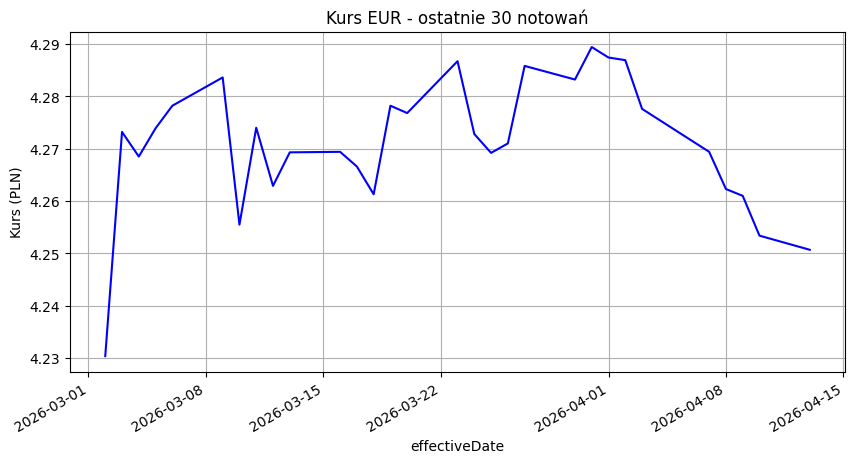

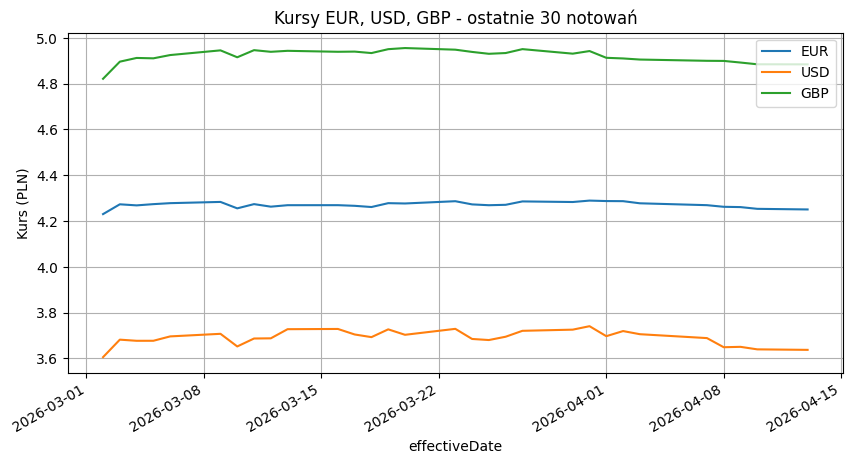

Najdroższe EUR w 2024 roku miało wartość 4.4016 PLN w dniu 2024-01-18


In [5]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

response_eur = requests.get("https://api.nbp.pl/api/exchangerates/rates/A/EUR/last/30/?format=json")
data_eur = response_eur.json()
print("Struktura odpowiedzi JSON (klucze):", data_eur.keys())
print("Przykładowy rekord 'rates':", data_eur['rates'][0])

df_eur = pd.json_normalize(data_eur['rates'])
df_eur['effectiveDate'] = pd.to_datetime(df_eur['effectiveDate'])
df_eur.set_index('effectiveDate', inplace=True)

plt.figure(figsize=(10, 5))
df_eur['mid'].plot(title="Kurs EUR - ostatnie 30 notowań", color='blue')
plt.ylabel("Kurs (PLN)")
plt.grid(True)
plt.show()

def pobierz_kurs_nbp(waluta):
    resp = requests.get(f"https://api.nbp.pl/api/exchangerates/rates/A/{waluta}/last/30/?format=json")
    df = pd.json_normalize(resp.json()['rates'])
    df['effectiveDate'] = pd.to_datetime(df['effectiveDate'])
    return df.set_index('effectiveDate')['mid'].rename(waluta)

df_usd = pobierz_kurs_nbp("USD")
df_gbp = pobierz_kurs_nbp("GBP")

df_all = pd.concat([df_eur['mid'].rename("EUR"), df_usd, df_gbp], axis=1)

plt.figure(figsize=(10, 5))
df_all.plot(ax=plt.gca(), title="Kursy EUR, USD, GBP - ostatnie 30 notowań")
plt.ylabel("Kurs (PLN)")
plt.grid(True)
plt.show()

df_all.to_parquet("kursy_walut_ostatnie_30.parquet")

resp_eur_2024 = requests.get("https://api.nbp.pl/api/exchangerates/rates/A/EUR/2024-01-01/2024-12-31/?format=json")
df_eur_2024 = pd.json_normalize(resp_eur_2024.json()['rates'])
df_eur_2024['effectiveDate'] = pd.to_datetime(df_eur_2024['effectiveDate'])
df_eur_2024.set_index('effectiveDate', inplace=True)

max_date = df_eur_2024['mid'].idxmax()
max_val = df_eur_2024['mid'].max()
print(f"Najdroższe EUR w 2024 roku miało wartość {max_val} PLN w dniu {max_date.date()}")

Zadanie 4: Benchmark formatów.
Plik: pomiary.csv (ok. 91 tys. wierszy, ~6 MB).
1. Wczytaj CSV do DataFrame.
2. Zapisz ten sam DataFrame jako: JSON, Parquet, HDF5, Pickle.
3. Zmierz rozmiary wszystkich plików na dysku. Zrób wykres słupkowy.Zmierz czas wczytywania każdego formatu (%timeit albo time.perf_counter).
4. Zrób drugi wykres.
5. Wczytaj tylko 2 kolumny z Parquet (columns=["date", "pm25"]) porównaj czas z wczytaniem wszystkich kolumn.
6. Wnioski: który format byś wybrał do długoterminowego przechowywania? Do szybkich analiz?

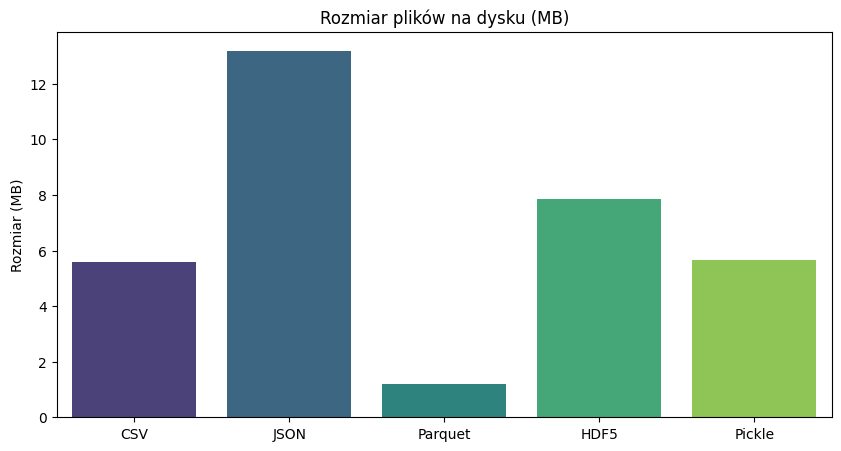

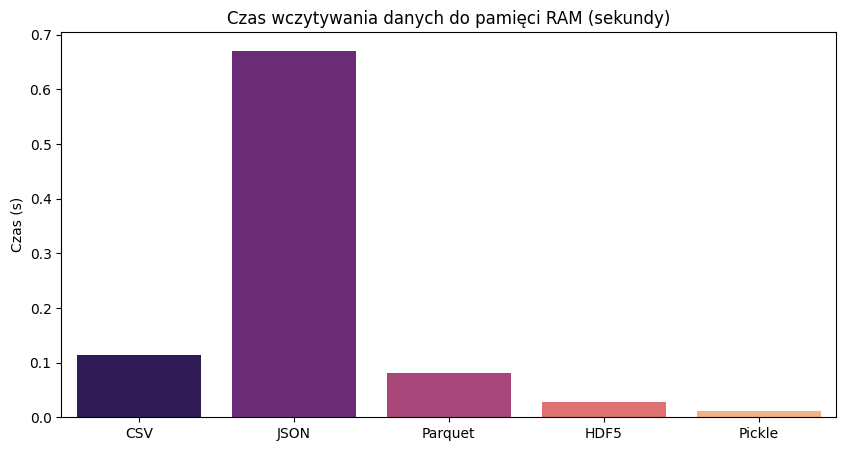

Czas odczytu Parquet (wszystkie kolumny): 0.02974 s
Czas odczytu Parquet (2 kolumny): 0.01031 s

Wnioski:
- Długoterminowe przechowywanie: Parquet, ze względu na duży stopień kompresji i mały rozmiar pliku.
- Szybkie analizy: Parquet / Pickle. Parquet jest w szczególności wysoce zoptymalizowany dla analizy kolumnowej, co minimalizuje czas ładowania i obciążenie pamięci (Pushdown Predicates / Column Pruning).


In [6]:
import pandas as pd
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("pomiary.csv")

df.to_json("pomiary.json")
df.to_parquet("pomiary.parquet")
df.to_hdf("pomiary.h5", key="data", mode="w")
df.to_pickle("pomiary.pkl")

formats = {
    "CSV": "pomiary.csv",
    "JSON": "pomiary.json",
    "Parquet": "pomiary.parquet",
    "HDF5": "pomiary.h5",
    "Pickle": "pomiary.pkl"
}

sizes_mb = {fmt: os.path.getsize(path) / (1024 * 1024) for fmt, path in formats.items()}

plt.figure(figsize=(10, 5))
sns.barplot(x=list(sizes_mb.keys()), y=list(sizes_mb.values()), hue=list(sizes_mb.keys()), palette="viridis")
plt.title("Rozmiar plików na dysku (MB)")
plt.ylabel("Rozmiar (MB)")
plt.show()

times = {}
for fmt, path in formats.items():
    start_time = time.perf_counter()
    if fmt == "CSV":
        pd.read_csv(path)
    elif fmt == "JSON":
        pd.read_json(path)
    elif fmt == "Parquet":
        pd.read_parquet(path)
    elif fmt == "HDF5":
        pd.read_hdf(path)
    elif fmt == "Pickle":
        pd.read_pickle(path)
    times[fmt] = time.perf_counter() - start_time

plt.figure(figsize=(10, 5))
sns.barplot(x=list(times.keys()), y=list(times.values()), hue=list(times.keys()), palette="magma")
plt.title("Czas wczytywania danych do pamięci RAM (sekundy)")
plt.ylabel("Czas (s)")
plt.show()

start_full = time.perf_counter()
pd.read_parquet("pomiary.parquet")
time_full = time.perf_counter() - start_full

start_part = time.perf_counter()
pd.read_parquet("pomiary.parquet", columns=["date", "pm25"])
time_part = time.perf_counter() - start_part

print(f"Czas odczytu Parquet (wszystkie kolumny): {time_full:.5f} s")
print(f"Czas odczytu Parquet (2 kolumny): {time_part:.5f} s")

print("\nWnioski:")
print("- Długoterminowe przechowywanie: Parquet, ze względu na duży stopień kompresji i mały rozmiar pliku.")
print("- Szybkie analizy: Parquet / Pickle. Parquet jest w szczególności wysoce zoptymalizowany dla analizy kolumnowej, co minimalizuje czas ładowania i obciążenie pamięci (Pushdown Predicates / Column Pruning).")

Zadanie 5: SQLite i pandas.
Plik: sklep.db.
Baza zawiera trzy tabele: klienci, produkty, zamowienia.
1. Podłącz się do bazy i wylistuj dostępne tabele (zapytanie do sqlite_master).
2. Wczytaj każdą z trzech tabel jako oddzielny DataFrame. Sprawdź rozmiary i typy kolumn.
3. Napisz zapytanie SQL, które zwraca 10 klientów z największą liczbą zamówień.
Dodatkowe:
1. Użyj chunksize w pd.read_sql, żeby wczytać tabelę zamowienia porcjami po 100 rekordów.Napisz zapytanie SQL, które zwraca sumaryczną wartość sprzedaży per kategoria produktu.
2. Zrób to samo w pandas.
3. Porównaj kod pod względem czytelności.

In [7]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("sklep.db")

query_tables = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query_tables, conn)
print("Dostępne tabele w bazie:\n", tables['name'].tolist(), "\n")

df_klienci = pd.read_sql_query("SELECT * FROM klienci;", conn)
df_produkty = pd.read_sql_query("SELECT * FROM produkty;", conn)
df_zamowienia = pd.read_sql_query("SELECT * FROM zamowienia;", conn)

print("Klienci - rozmiar:", df_klienci.shape, "\nTypy:\n", df_klienci.dtypes, "\n")
print("Produkty - rozmiar:", df_produkty.shape, "\nTypy:\n", df_produkty.dtypes, "\n")
print("Zamówienia - rozmiar:", df_zamowienia.shape, "\nTypy:\n", df_zamowienia.dtypes, "\n")

sql_top_10 = """
SELECT klient_id, COUNT(*) as liczba_zamowien
FROM zamowienia
GROUP BY klient_id
ORDER BY liczba_zamowien DESC
LIMIT 10;
"""
df_top_10 = pd.read_sql_query(sql_top_10, conn)
print("Top 10 klientów (SQL):\n", df_top_10, "\n")

chunks = pd.read_sql_query("SELECT * FROM zamowienia;", conn, chunksize=100)
for i, chunk in enumerate(chunks):
    if i == 0:
        print(f"Pierwsza porcja zamówień: wczytano {len(chunk)} rekordów.\n")
        break

sql_sales_category = """
SELECT p.kategoria, SUM(z.ilosc * p.cena) as wartosc_sprzedazy
FROM zamowienia z
JOIN produkty p ON z.produkt_id = p.id
GROUP BY p.kategoria;
"""
df_sales_sql = pd.read_sql_query(sql_sales_category, conn)
print("Sprzedaż per kategoria (SQL):\n", df_sales_sql, "\n")

df_merged = df_zamowienia.merge(df_produkty, left_on='produkt_id', right_on='id')
df_merged['wartosc'] = df_merged['ilosc'] * df_merged['cena']
df_sales_pandas = df_merged.groupby('kategoria')['wartosc'].sum().reset_index()
print("Sprzedaż per kategoria (Pandas):\n", df_sales_pandas, "\n")

print("Porównanie czytelności:")
print("Kod SQL w przypadku joinów i agregacji często jest krótszy, naturalniejszy i wykonuje operacje na poziomie silnika bazy danych (co odciąża RAM w Pythonie).")
print("Kod w pandas w tym przypadku wymaga alokacji pośredniego DataFrame (z wynikiem merge), zdefiniowania nowej kolumny na wynik operacji arytmetycznej, a dopiero potem wykonania funkcji .groupby() i .sum().")

conn.close()

Dostępne tabele w bazie:
 ['klienci', 'produkty', 'zamowienia'] 

Klienci - rozmiar: (200, 6) 
Typy:
 id                   int64
imie                object
nazwisko            object
miasto              object
wiek                 int64
data_rejestracji    object
dtype: object 

Produkty - rozmiar: (15, 4) 
Typy:
 id             int64
nazwa         object
kategoria     object
cena         float64
dtype: object 

Zamówienia - rozmiar: (1000, 5) 
Typy:
 id                  int64
klient_id           int64
produkt_id          int64
ilosc               int64
data_zamowienia    object
dtype: object 

Top 10 klientów (SQL):
    klient_id  liczba_zamowien
0        174               10
1        170               10
2         72               10
3        166                9
4        164                9
5        163                9
6        147                9
7        138                9
8        102                9
9         99                9 

Pierwsza porcja zamówień: wczytano 100 rek